In [2]:
# Exploratory Data Analysis on Netflix Dataset

## Objective: To analyze Netflix content such as movies and TV shows to understand trends in genres, countries, release years, and ratings.

In [3]:
# import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
# loading Datasets

df = pd.read_csv(r"C:\Users\amans\Downloads\netflix_movies (1).csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Basic Information

df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,15-Aug,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [6]:
# Check Missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [23]:
# Fill missing values for important columns
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')

# Drop rows where critical columns are missing
df = df.dropna(subset=['date_added', 'rating'])

In [24]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [9]:
# Rename columns
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [10]:
# Convert date types
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year
df['year_added'] = df['date_added'].dt.year

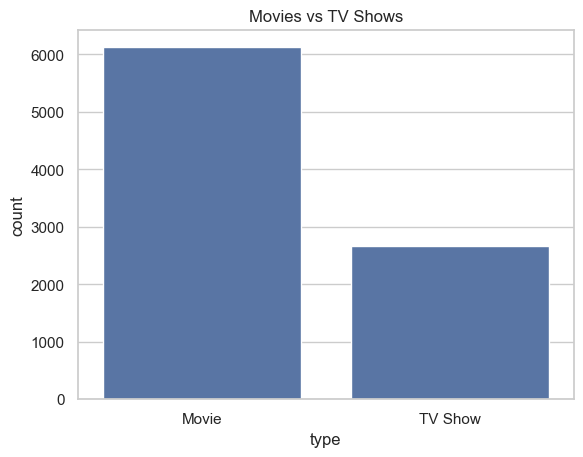

In [12]:
# Content Type Distributions
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

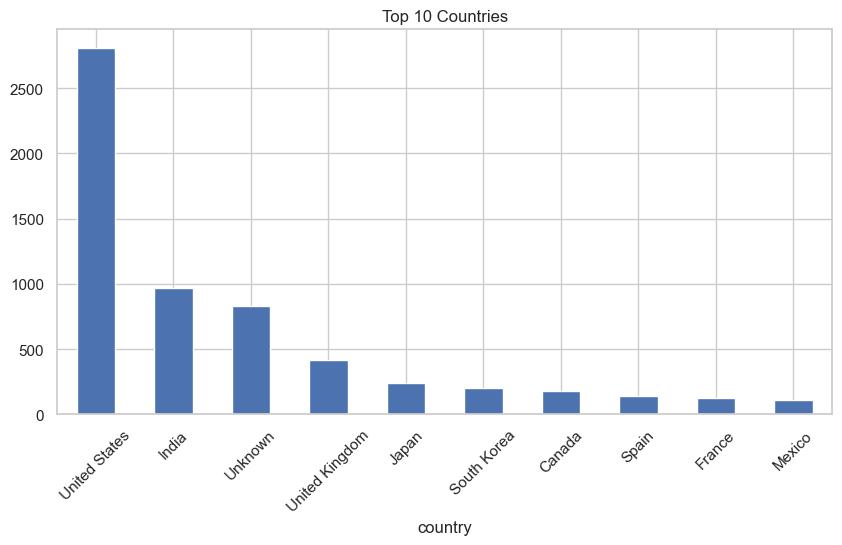

In [13]:
# Top 10 Countries
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries")
plt.xticks(rotation=45)
plt.show()

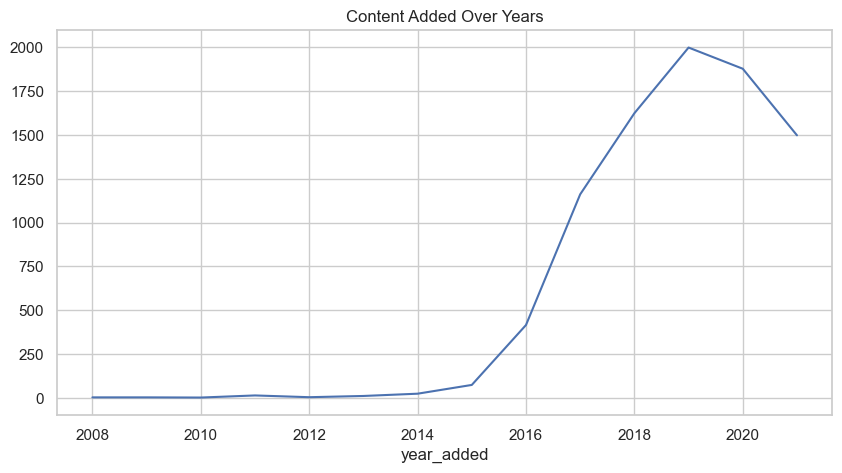

In [14]:
# Content Added over Years
df['year_added'].value_counts().sort_index().plot(kind='line', figsize=(10,5))
plt.title("Content Added Over Years")
plt.show()

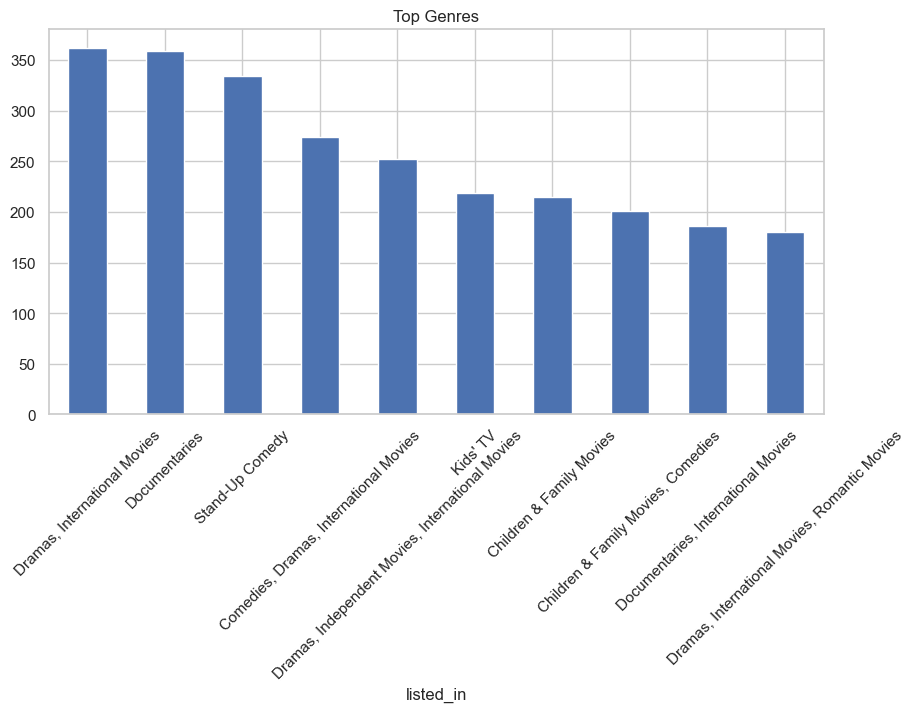

In [15]:
# Top Genres
df['listed_in'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Genres")
plt.xticks(rotation=45)
plt.show()

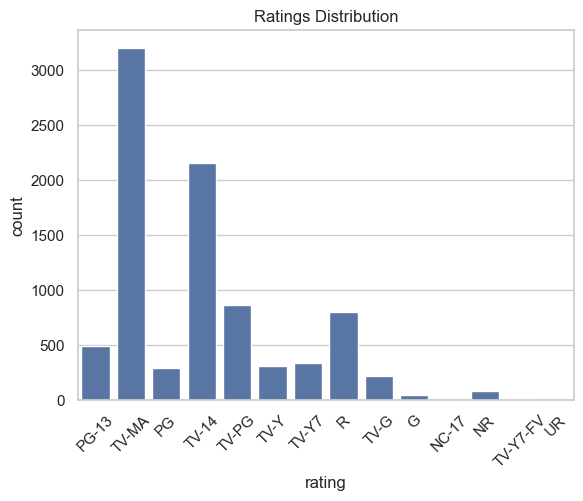

In [16]:
# Rating Distributions
sns.countplot(x='rating', data=df)
plt.title("Ratings Distribution")
plt.xticks(rotation=45)
plt.show()

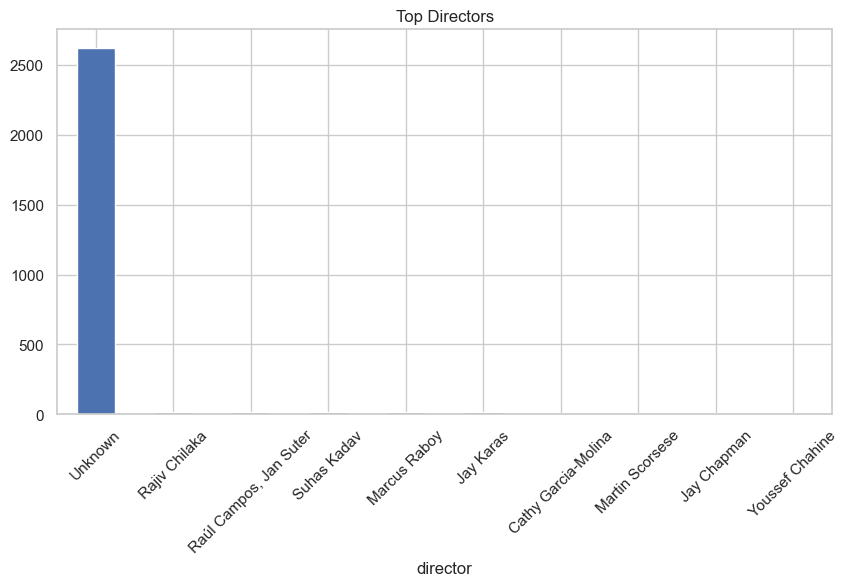

In [17]:
# Top Directors
df['director'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Directors")
plt.xticks(rotation=45)
plt.show()

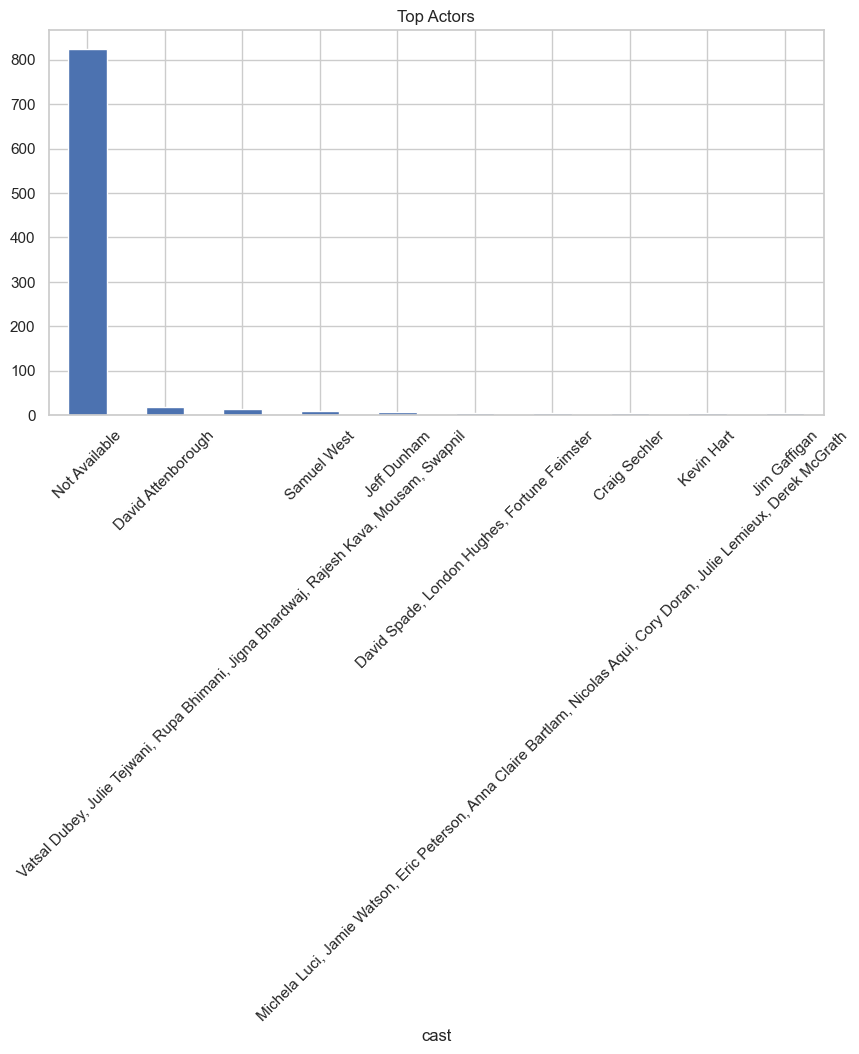

In [18]:
# Top casts
df['cast'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Actors")
plt.xticks(rotation=45)
plt.show()

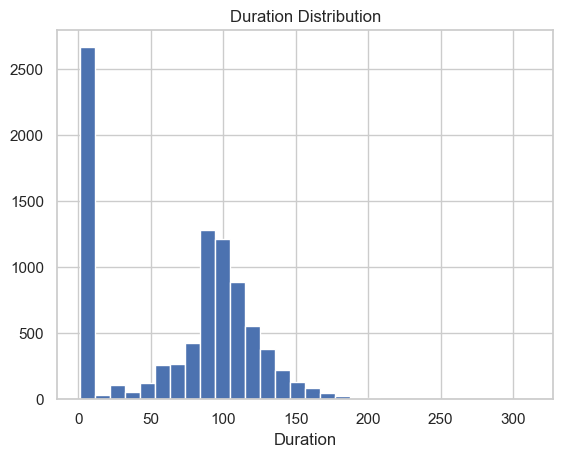

In [19]:
# Histogram
plt.hist(df['duration_num'].dropna(), bins=30)
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.show()

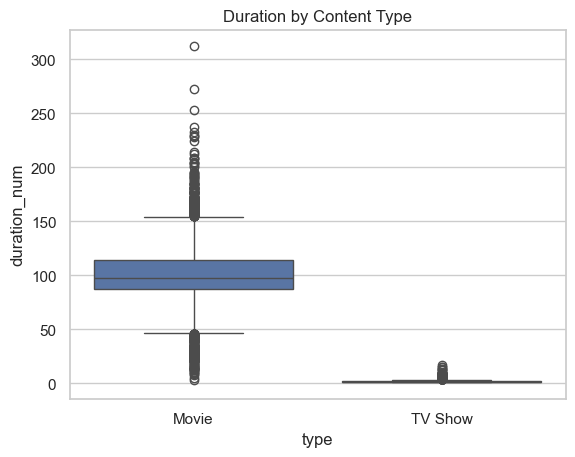

In [20]:
# Box plot
sns.boxplot(x='type', y='duration_num', data=df)
plt.title("Duration by Content Type")
plt.show()

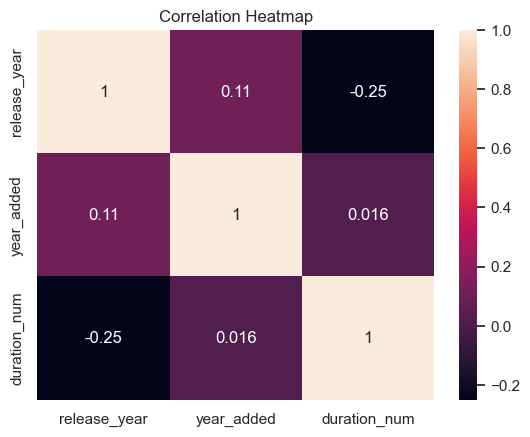

In [21]:
# Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()